# Habitat 3.0 Benchmarking

In [15]:
%%bash
rm -f /content/habitat-lab-v033/data/profile/hab3/1_300_-1_*_[4-9].txt
ls /content/habitat-lab-v033/data/profile/hab3/ | wc -l

21


In [16]:
%%bash
# Symlinks from notebooks 08/09
mkdir -p /content/data/objects /content/data/robots

ln -sfn /content/drive/MyDrive/HabitatData/versioned_data/hab3_bench_assets /content/data/hab3_bench_assets
ln -sfn /content/drive/MyDrive/HabitatData/versioned_data/ycb /content/data/objects/ycb
ln -sfn /content/drive/MyDrive/HabitatData/versioned_data/hab_spot_arm /content/data/robots/hab_spot_arm

ln -sfn /content/data /content/habitat-lab-v033/data 2>/dev/null || true

cat > /tmp/nvidia_egl.json << 'EOF'
{"file_format_version":"1.0.0","ICD":{"library_path":"libEGL_nvidia.so.0"}}
EOF

# Restore clean YAMLs from GitHub, then patch them.
# Adds measure dependencies required by move_obj_reward / rearrange_cooperate_reward
# (must come BEFORE the reward measure in the list).
CFG_DIR=/content/habitat-lab-v033/habitat-lab/habitat/config/benchmark/rearrange/hab3_bench
BASE=https://raw.githubusercontent.com/facebookresearch/habitat-lab/v0.3.3/habitat-lab/habitat/config/benchmark/rearrange/hab3_bench

for f in single_agent_bench.yaml multi_agent_bench.yaml; do
  curl -fsSL "$BASE/$f" -o "$CFG_DIR/$f"
done

python3 - <<'PY'
import re, os
deps = [
    "articulated_agent_force",
    "force_terminate",
    "object_to_goal_distance",
    "end_effector_to_object_distance",
]
cfg_dir = "/content/habitat-lab-v033/habitat-lab/habitat/config/benchmark/rearrange/hab3_bench"
for fname in ["single_agent_bench.yaml", "multi_agent_bench.yaml"]:
    p = os.path.join(cfg_dir, fname)
    s = open(p).read()
    target = "move_objects_reward" if "move_objects_reward" in s else "rearrange_cooperate_reward"
    m = re.search(r"(\n)(\s+)- " + target, s)
    if not m:
        print(f"{fname}: no anchor found, skipping"); continue
    indent = m.group(2)
    insertion = "".join(f"\n{indent}- {d}" for d in deps)
    s = s.replace(f"\n{indent}- {target}", f"{insertion}\n{indent}- {target}", 1)
    open(p, "w").write(s)
    print(f"patched {fname}: inserted deps before {target}")
PY
echo "Ready"

patched single_agent_bench.yaml: inserted deps before move_objects_reward
patched multi_agent_bench.yaml: inserted deps before rearrange_cooperate_reward
Ready


## 2. Inspect the official benchmark configs


In [17]:
%%bash
ls /content/habitat-lab-v033/habitat-lab/habitat/config/benchmark/rearrange/hab3_bench/

humanoid_oracle.yaml
multi_agent_bench.yaml
single_agent_bench.yaml
spot_humanoid_oracle.yaml
spot_oracle.yaml
spot_spot_oracle.yaml


In [18]:
%%bash
source /opt/conda/etc/profile.d/conda.sh && conda activate habitatEnv
pip install psutil
python -c "import psutil; print('psutil', psutil.__version__)"


psutil 7.2.2


In [19]:
%%bash
source /opt/conda/etc/profile.d/conda.sh && conda activate habitatEnv
cd /content/habitat-lab-v033
if [ -d data/replica_cad ] && [ "$(ls -A data/replica_cad 2>/dev/null)" ]; then
  echo "replica_cad already present, skipping download"
else
  python -m habitat_sim.utils.datasets_download --uids replica_cad_dataset --data-path data/ --no-replace --no-prune
fi
ls data/replica_cad/ | head

replica_cad already present, skipping download
configs
LICENSE.txt
navmeshes
navmeshes_default
objects
README.md
replicaCAD.scene_dataset_config.json
stages
urdf


## 3. Benchmark 1: Single Spot robot with oracle nav


In [20]:
%%bash
source /opt/conda/etc/profile.d/conda.sh && conda activate habitatEnv
cd /content/habitat-lab-v033
export MAGNUM_LOG=quiet
export HABITAT_SIM_LOG=quiet
export __EGL_VENDOR_LIBRARY_FILENAMES=/tmp/nvidia_egl.json
export LD_LIBRARY_PATH=$(dirname $(find /usr -name "libEGL_nvidia.so.0" 2>/dev/null | head -1)):$LD_LIBRARY_PATH
export NVIDIA_DRIVER_CAPABILITIES=all
export OMP_NUM_THREADS=2

mkdir -p data/profile

for i in 1 2 3; do
  echo "=== robot_oracle trial $i ==="
  python scripts/hab3_bench/hab3_benchmark.py \
      --cfg benchmark/rearrange/hab3_bench/spot_oracle.yaml \
      --n-steps 300 --n-procs 1 \
      --out-name "robot_oracle_$i" \
      habitat.task.task_spec=tidy_house_2obj \
      habitat.task.pddl_domain_def=fp \
      habitat.dataset.data_path=data/hab3_bench_assets/episode_datasets/small_small.json.gz 2>&1 | tail -5
done
ls -1 data/profile/hab3/ | grep "^1_300_-1_robot_oracle_[0-9]"

=== robot_oracle trial 1 ===

Wrote result to  data/profile/hab3/1_300_-1_robot_oracle_1.txt
Ran 1 trial(s) with average FPS of 182.26551121031616 from [182.26551121031616].
=== robot_oracle trial 2 ===

Wrote result to  data/profile/hab3/1_300_-1_robot_oracle_2.txt
Ran 1 trial(s) with average FPS of 259.9873377948868 from [259.9873377948868].
=== robot_oracle trial 3 ===

Wrote result to  data/profile/hab3/1_300_-1_robot_oracle_3.txt
Ran 1 trial(s) with average FPS of 205.40578659719094 from [205.40578659719094].
1_300_-1_robot_oracle_10obj_small_scn_1.txt
1_300_-1_robot_oracle_10obj_small_scn_2.txt
1_300_-1_robot_oracle_10obj_small_scn_3.txt
1_300_-1_robot_oracle_1.txt
1_300_-1_robot_oracle_2obj_small_scn_1.txt
1_300_-1_robot_oracle_2obj_small_scn_2.txt
1_300_-1_robot_oracle_2obj_small_scn_3.txt
1_300_-1_robot_oracle_2.txt
1_300_-1_robot_oracle_3.txt
1_300_-1_robot_oracle_5obj_small_scn_1.txt
1_300_-1_robot_oracle_5obj_small_scn_2.txt
1_300_-1_robot_oracle_5obj_small_scn_3.txt


## 4. Benchmark 2: Single Humanoid with oracle nav


In [21]:
%%bash
source /opt/conda/etc/profile.d/conda.sh && conda activate habitatEnv
cd /content/habitat-lab-v033
export MAGNUM_LOG=quiet
export HABITAT_SIM_LOG=quiet
export __EGL_VENDOR_LIBRARY_FILENAMES=/tmp/nvidia_egl.json
export LD_LIBRARY_PATH=$(dirname $(find /usr -name "libEGL_nvidia.so.0" 2>/dev/null | head -1)):$LD_LIBRARY_PATH
export NVIDIA_DRIVER_CAPABILITIES=all
export OMP_NUM_THREADS=2

for i in 1 2 3; do
  echo "=== human_oracle trial $i ==="
  python scripts/hab3_bench/hab3_benchmark.py \
      --cfg benchmark/rearrange/hab3_bench/humanoid_oracle.yaml \
      --n-steps 300 --n-procs 1 \
      --out-name "human_oracle_$i" \
      habitat.task.task_spec=tidy_house_2obj \
      habitat.task.pddl_domain_def=fp \
      habitat.dataset.data_path=data/hab3_bench_assets/episode_datasets/small_small.json.gz 2>&1 | tail -5
done
ls -1 data/profile/hab3/ | grep "^1_300_-1_human_oracle_[0-9]"

=== human_oracle trial 1 ===

Wrote result to  data/profile/hab3/1_300_-1_human_oracle_1.txt
Ran 1 trial(s) with average FPS of 201.20369400847625 from [201.20369400847625].
=== human_oracle trial 2 ===

Wrote result to  data/profile/hab3/1_300_-1_human_oracle_2.txt
Ran 1 trial(s) with average FPS of 137.82080876978355 from [137.82080876978355].
=== human_oracle trial 3 ===

Wrote result to  data/profile/hab3/1_300_-1_human_oracle_3.txt
Ran 1 trial(s) with average FPS of 200.51144797063347 from [200.51144797063347].
1_300_-1_human_oracle_1.txt
1_300_-1_human_oracle_2.txt
1_300_-1_human_oracle_3.txt


## 5. Benchmark 3: Multi-agent Spot + Spot


In [22]:
%%bash
source /opt/conda/etc/profile.d/conda.sh && conda activate habitatEnv
cd /content/habitat-lab-v033
export MAGNUM_LOG=quiet
export HABITAT_SIM_LOG=quiet
export __EGL_VENDOR_LIBRARY_FILENAMES=/tmp/nvidia_egl.json
export LD_LIBRARY_PATH=$(dirname $(find /usr -name "libEGL_nvidia.so.0" 2>/dev/null | head -1)):$LD_LIBRARY_PATH
export NVIDIA_DRIVER_CAPABILITIES=all
export OMP_NUM_THREADS=2

for i in 1 2 3; do
  echo "=== robots_oracle trial $i ==="
  python scripts/hab3_bench/hab3_benchmark.py \
      --cfg benchmark/rearrange/hab3_bench/spot_spot_oracle.yaml \
      --n-steps 300 --n-procs 1 \
      --out-name "robots_oracle_$i" \
      habitat.task.pddl_domain_def=fp \
      habitat.dataset.data_path=data/hab3_bench_assets/episode_datasets/small_small.json.gz 2>&1 | tail -5
done
ls -1 data/profile/hab3/ | grep "^1_300_-1_robots_oracle_[0-9]"

=== robots_oracle trial 1 ===

Wrote result to  data/profile/hab3/1_300_-1_robots_oracle_1.txt
Ran 1 trial(s) with average FPS of 126.81105296547108 from [126.81105296547108].
=== robots_oracle trial 2 ===

Wrote result to  data/profile/hab3/1_300_-1_robots_oracle_2.txt
Ran 1 trial(s) with average FPS of 141.55714373829665 from [141.55714373829665].
=== robots_oracle trial 3 ===

Wrote result to  data/profile/hab3/1_300_-1_robots_oracle_3.txt
Ran 1 trial(s) with average FPS of 142.0800001495151 from [142.0800001495151].
1_300_-1_robots_oracle_1.txt
1_300_-1_robots_oracle_2.txt
1_300_-1_robots_oracle_3.txt


## 6. Benchmark 4: Multi-agent Spot + Humanoid


In [23]:
%%bash
source /opt/conda/etc/profile.d/conda.sh && conda activate habitatEnv
cd /content/habitat-lab-v033
export MAGNUM_LOG=quiet
export HABITAT_SIM_LOG=quiet
export __EGL_VENDOR_LIBRARY_FILENAMES=/tmp/nvidia_egl.json
export LD_LIBRARY_PATH=$(dirname $(find /usr -name "libEGL_nvidia.so.0" 2>/dev/null | head -1)):$LD_LIBRARY_PATH
export NVIDIA_DRIVER_CAPABILITIES=all
export OMP_NUM_THREADS=2

for i in 1 2 3; do
  echo "=== robot_human_oracle trial $i ==="
  python scripts/hab3_bench/hab3_benchmark.py \
      --cfg benchmark/rearrange/hab3_bench/spot_humanoid_oracle.yaml \
      --n-steps 300 --n-procs 1 \
      --out-name "robot_human_oracle_$i" \
      habitat.task.end_on_success=False \
      habitat.task.measurements.rearrange_cooperate_reward.end_on_collide=False \
      habitat.task.pddl_domain_def=fp \
      habitat.dataset.data_path=data/hab3_bench_assets/episode_datasets/small_small.json.gz 2>&1 | tail -5
done
ls -1 data/profile/hab3/ | grep "^1_300_-1_robot_human_oracle_[0-9]"

=== robot_human_oracle trial 1 ===

Wrote result to  data/profile/hab3/1_300_-1_robot_human_oracle_1.txt
Ran 1 trial(s) with average FPS of 112.07096041553895 from [112.07096041553895].
=== robot_human_oracle trial 2 ===

Wrote result to  data/profile/hab3/1_300_-1_robot_human_oracle_2.txt
Ran 1 trial(s) with average FPS of 133.98894511043983 from [133.98894511043983].
=== robot_human_oracle trial 3 ===

Wrote result to  data/profile/hab3/1_300_-1_robot_human_oracle_3.txt
Ran 1 trial(s) with average FPS of 101.5638154218585 from [101.5638154218585].
1_300_-1_robot_human_oracle_1.txt
1_300_-1_robot_human_oracle_2.txt
1_300_-1_robot_human_oracle_3.txt


## 7. Benchmark 1 dataset sweep (small scenes only)
The medium/large episode datasets reference HSSD scenes whose semantic asset chain is broken in v0.3.3 on this setup, so we run only the 3 small-scene variants (`2obj`, `5obj`, `10obj` × small scene) × 3 trials = 9 runs.

In [24]:
%%bash
source /opt/conda/etc/profile.d/conda.sh && conda activate habitatEnv
cd /content/habitat-lab-v033
export MAGNUM_LOG=quiet
export HABITAT_SIM_LOG=quiet
export __EGL_VENDOR_LIBRARY_FILENAMES=/tmp/nvidia_egl.json
export LD_LIBRARY_PATH=$(dirname $(find /usr -name "libEGL_nvidia.so.0" 2>/dev/null | head -1)):$LD_LIBRARY_PATH
export NVIDIA_DRIVER_CAPABILITIES=all
export OMP_NUM_THREADS=2

# Small-scene only (medium/large need HSSD assets that aren't wired up).
# Filename pattern: <sceneSize>_<objClass>.json.gz where small=2obj, medium=5obj, large=10obj.
postfixes=("2obj_small_scn"      "5obj_small_scn"        "10obj_small_scn")
datasets=( "small_small.json.gz" "small_medium.json.gz"  "small_large.json.gz")

for i in 1 2 3; do
  for ix in "${!postfixes[@]}"; do
    name="robot_oracle_${postfixes[$ix]}_$i"
    echo "=== $name ==="
    python scripts/hab3_bench/hab3_benchmark.py \
        --cfg benchmark/rearrange/hab3_bench/spot_oracle.yaml \
        --n-steps 300 --n-procs 1 \
        --out-name "$name" \
        habitat.task.task_spec=tidy_house_2obj \
        habitat.task.pddl_domain_def=fp \
        "habitat.dataset.data_path=data/hab3_bench_assets/episode_datasets/${datasets[$ix]}" 2>&1 | tail -3
  done
done
ls -1 data/profile/hab3/ | grep "^1_300_-1_robot_oracle_.*obj_small_scn_"

=== robot_oracle_2obj_small_scn_1 ===
Ran 1 trial(s) with average FPS of 256.2499204714997 from [256.2499204714997].
=== robot_oracle_5obj_small_scn_1 ===
Ran 1 trial(s) with average FPS of 173.86138523287326 from [173.86138523287326].
=== robot_oracle_10obj_small_scn_1 ===
Ran 1 trial(s) with average FPS of 236.47012279512444 from [236.47012279512444].
=== robot_oracle_2obj_small_scn_2 ===
Ran 1 trial(s) with average FPS of 261.73915045628775 from [261.73915045628775].
=== robot_oracle_5obj_small_scn_2 ===
Ran 1 trial(s) with average FPS of 235.60018625681903 from [235.60018625681903].
=== robot_oracle_10obj_small_scn_2 ===
Ran 1 trial(s) with average FPS of 230.04272728373095 from [230.04272728373095].
=== robot_oracle_2obj_small_scn_3 ===
Ran 1 trial(s) with average FPS of 190.46273424634282 from [190.46273424634282].
=== robot_oracle_5obj_small_scn_3 ===
Ran 1 trial(s) with average FPS of 236.05205709194527 from [236.05205709194527].
=== robot_oracle_10obj_small_scn_3 ===
Ran 1 tri

In [25]:
%%bash
cd /content/habitat-lab-v033/data/profile/hab3
echo "=== files per variant ==="
for v in robot_human_oracle robots_oracle human_oracle robot_oracle \
         robot_oracle_2obj_small_scn robot_oracle_2obj_medium_scn robot_oracle_2obj_large_scn \
         robot_oracle_5obj_small_scn robot_oracle_5obj_medium_scn robot_oracle_5obj_large_scn \
         robot_oracle_10obj_small_scn robot_oracle_10obj_medium_scn robot_oracle_10obj_large_scn; do
  count=$(ls 1_300_-1_${v}_[0-9]*.txt 2>/dev/null | wc -l)
  echo "$count  $v"
done


=== files per variant ===
3  robot_human_oracle
3  robots_oracle
3  human_oracle
12  robot_oracle
3  robot_oracle_2obj_small_scn
0  robot_oracle_2obj_medium_scn
0  robot_oracle_2obj_large_scn
3  robot_oracle_5obj_small_scn
0  robot_oracle_5obj_medium_scn
0  robot_oracle_5obj_large_scn
3  robot_oracle_10obj_small_scn
0  robot_oracle_10obj_medium_scn
0  robot_oracle_10obj_large_scn


In [26]:
%%bash
source /opt/conda/etc/profile.d/conda.sh && conda activate habitatEnv
cd /content/habitat-lab-v033
export MAGNUM_LOG=quiet
export HABITAT_SIM_LOG=quiet
export __EGL_VENDOR_LIBRARY_FILENAMES=/tmp/nvidia_egl.json
export LD_LIBRARY_PATH=$(dirname $(find /usr -name "libEGL_nvidia.so.0" 2>/dev/null | head -1)):$LD_LIBRARY_PATH
export NVIDIA_DRIVER_CAPABILITIES=all
export OMP_NUM_THREADS=2

python scripts/hab3_bench/hab3_benchmark.py \
    --cfg benchmark/rearrange/hab3_bench/spot_oracle.yaml \
    --n-steps 50 --n-procs 1 \
    --out-name "diag_2obj_medium" \
    habitat.task.task_spec=tidy_house_2obj \
    habitat.task.pddl_domain_def=fp \
    habitat.dataset.data_path=data/hab3_bench_assets/episode_datasets/medium_small.json.gz 2>&1 | tail -30


PluginManager::Manager: duplicate static plugin AnySceneImporter, ignoring
PluginManager::Manager: duplicate static plugin AnyImageImporter, ignoring
assigning 0 gpu 0
Traceback (most recent call last):
  File "/content/habitat-lab-v033/scripts/hab3_bench/hab3_benchmark.py", line 248, in <module>
    profile_sums = bench.benchmark()
  File "/content/habitat-lab-v033/scripts/hab3_bench/hab3_benchmark.py", line 186, in benchmark
    return self._bench_target()
  File "/content/habitat-lab-v033/scripts/hab3_bench/hab3_benchmark.py", line 115, in _bench_target
    self.init_common(_idx)
  File "/content/habitat-lab-v033/scripts/hab3_bench/hab3_benchmark.py", line 150, in init_common
    self.envs = create_env(self.args, proc_idx)
  File "/content/habitat-lab-v033/scripts/hab3_bench/hab3_benchmark.py", line 31, in create_env
    return habitat.Env(config=config)
  File "/content/habitat-lab-v033/habitat-lab/habitat/core/env.py", line 114, in __init__
    self._sim = make_sim(
  File "/conte

## 8. Plot results with h3_plot_bench.py
Two patches: skip `n_procs=16` (Colab can't run 16 sim processes), and restrict the auto-generated dataset variants to `scenes=["small"]` (medium/large need HSSD assets we don't have). Output: `data/profile/opts_1.pdf`.

In [27]:
%%bash
source /opt/conda/etc/profile.d/conda.sh && conda activate habitatEnv
cd /content/habitat-lab-v033
unset MPLBACKEND
export MPLBACKEND=Agg

# Re-fetch clean script then patch:
#   1. n_procs loop [1, 16] -> [1] (Colab can't run 16 procs)
#   2. scenes list -> only "small" (HSSD medium/large not wired up)
curl -fsSL "https://raw.githubusercontent.com/facebookresearch/habitat-lab/v0.3.3/scripts/hab3_bench/h3_plot_bench.py" \
  -o scripts/hab3_bench/h3_plot_bench.py

python3 - <<'PY'
import re
p = "scripts/hab3_bench/h3_plot_bench.py"
s = open(p).read()
s = re.sub(r"for i in \[1, 16\]:", "for i in [1]:", s)
s = s.replace('scenes = ["large", "medium", "small"]', 'scenes = ["small"]')
open(p, "w").write(s)
print("patched (n_procs=16 skipped, scenes=[small] only)")
PY

python scripts/hab3_bench/h3_plot_bench.py
ls -lh data/profile/opts_*.pdf

patched (n_procs=16 skipped, scenes=[small] only)
[('robot_human_oracle', '[Robot-Human Oracle Paths]'), ('robots_oracle', '[Robots Oracle]'), ('human_oracle', '[Human Oracle]'), ('robot_oracle', '[Robot Oracle]'), ('robot_oracle_10obj_small_scn', '[robot_oracle: O=10 S=small]'), ('robot_oracle_5obj_small_scn', '[robot_oracle: O=5 S=small]'), ('robot_oracle_2obj_small_scn', '[robot_oracle: O=2 S=small]')]
data/profile/hab3/1_300_-1_robot_human_oracle_1.txt
data/profile/hab3/1_300_-1_robot_human_oracle_2.txt
data/profile/hab3/1_300_-1_robot_human_oracle_3.txt
data/profile/hab3/1_300_-1_robot_human_oracle_4.txt
data/profile/hab3/1_300_-1_robots_oracle_1.txt
data/profile/hab3/1_300_-1_robots_oracle_2.txt
data/profile/hab3/1_300_-1_robots_oracle_3.txt
data/profile/hab3/1_300_-1_robots_oracle_4.txt
data/profile/hab3/1_300_-1_human_oracle_1.txt
data/profile/hab3/1_300_-1_human_oracle_2.txt
data/profile/hab3/1_300_-1_human_oracle_3.txt
data/profile/hab3/1_300_-1_human_oracle_4.txt
data/profil

## 9. View the plot inline
Convert PDF → PNG via poppler so it renders in the notebook output.

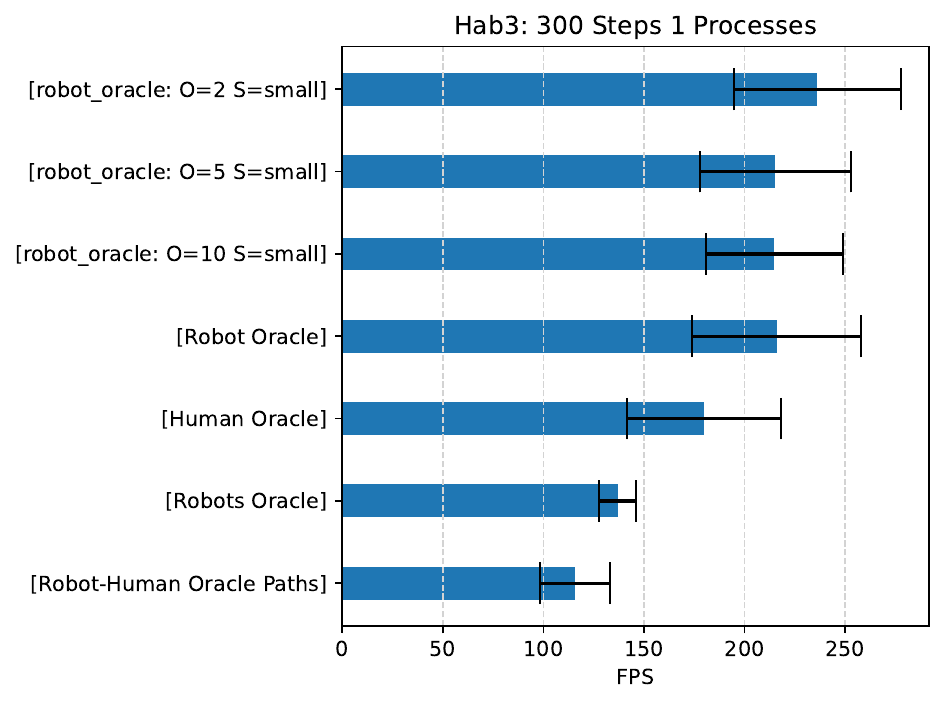

In [28]:
import subprocess, os
from PIL import Image
from IPython.display import display

pdf = "/content/habitat-lab-v033/data/profile/opts_1.pdf"
png_prefix = "/content/habitat-lab-v033/data/profile/opts_1"
png = png_prefix + "-1.png"

# Install poppler if pdftoppm isn't on PATH
if subprocess.call(["which", "pdftoppm"], stdout=subprocess.DEVNULL) != 0:
    subprocess.run(["apt-get", "install", "-y", "-q", "poppler-utils"], check=True)

subprocess.run(["pdftoppm", "-png", "-r", "150", pdf, png_prefix], check=True)
display(Image.open(png))